In [220]:
import requests
from bs4 import BeautifulSoup
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from numpy import e

In [140]:
class ParserException(Exception):
  pass

class HHparserException(ParserException):
  pass

class HHParserNotParsedException(HHparserException):
  pass

In [235]:
class HHParser:
  def __init__(self, name, russian_query, area=1):
    self.query = name
    self.russian_query = russian_query
    self.url = f"https://hh.ru/vacancies/{self.query}"
    self.area = area
    self.headers = {'User-Agent': 'Mozilla/5.0...'}
    self.full_html = ''

  def parse(self, start_page, end_page):
    all = []
    with requests.Session() as session:
      session.headers.update(self.headers)
      for i in range(start_page, end_page+1):
        r = session.get(self.url, params={
            #'text': self.query, 'area': self.area, 'per_page': 50,
            'page': i}, timeout = 10)
        r.raise_for_status()
        html = r.text
        self.full_html = self.full_html + html
        soup = BeautifulSoup(html)
        jobs = soup.find_all('a', attrs={'data-qa': "serp-item__title"})
        all.extend(jobs)
    return all

  def get_salary_and_name(self, cards: list):
    all, only_with_salaries = [], []
    for j in cards:
      salary = j.parent.parent.find('span', class_=lambda c: c and 'label-1-regular' in c)
      job_type = j.parent.parent.find('span', {'data-qa': 'serp-item__title-text'}).get_text()
      if salary is None:
        new = (job_type, None, None)
        all.append(new)
        continue
      sal = re.sub(r'\s+', ' ', salary.get_text())
      lili = sal.split()
      first, second = None, None
      first_got = False
      for i in range(0, len(lili)):
        if lili[i].isdigit() == True and lili[i+1] == '000' and first_got == False:
          first = int(lili[i] + lili[i+1])
          first_got = True
        if i!=len(lili) and lili[i].isdigit() == True and lili[i+1] == '000' and first_got == True:
          second = int(lili[i] + lili[i+1])
      new = (job_type, first, second)
      all.append(new)
      only_with_salaries.append(new)
    self.jobs = all
    self.jobs_with_sal = only_with_salaries

  def make_pandas(self):
    starts, ends, names = [], [], []
    if not hasattr(self, 'jobs_with_sal'):
      raise HHParserNotParsedException('вы не пропарсили еще')
    for name, start, end in self.jobs_with_sal:
      starts.append(start)
      ends.append(end)
      names.append(name)
    st, en, na = pd.Series(starts), pd.Series(ends), pd.Series(names)
    df = pd.DataFrame({'job': na, 'min': st, 'max': en})
    df['average'] = (df['min']+df['max'])/2
    self.df = df

  def clean_pandas(self, job):
    clean_df = self.df[self.df['job'].str.contains(job, case=False)]
    clean_clean_df = clean_df.dropna()
    self.df = clean_clean_df

  def make_graphics(self):
    if not hasattr(self, 'df'):
      raise HHParserNotParsedException('айайай датафрейм не создан, надо работать через make_everything')
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Зарплаты: {self.russian_query}', fontsize=14)

    axes[0].hist(self.df['average'].dropna(), bins=10, color='steelblue', edgecolor='white');
    axes[0].set_title('Распределение зарплат')
    axes[0].set_xlabel('Зарплата (руб.)')
    axes[0].set_ylabel('Кол-во вакансий')
    axes[0].axvline(self.mean, color='red', linestyle='--', label=f'среднее: {self.mean}')
    axes[0].legend()

    axes[1].boxplot([self.df['min'].dropna(), self.df['max'].dropna()], tick_labels=['Минимальная', 'Максимальная']);
    axes[1].set_title('Разброс зарплат');
    axes[1].set_ylabel('Зарплата (руб.)');

    top = self.df.groupby('job')['average'].mean().sort_values(ascending=True).tail(10);
    axes[2].barh(top.index, top.values, color='steelblue');
    axes[2].set_title('Топ должностей по средней зарплате');
    axes[2].set_xlabel('Средняя зарплата (руб.)');

    plt.tight_layout();

  def make_everything(self, start_page: int = 0, end_page: int = 5):
    li = self.parse(start_page, end_page)
    self.get_salary_and_name(li)
    self.make_pandas()
    self.clean_pandas(self.russian_query)
    self.mean = round(self.df['average'].mean(), 1).item()
    self.make_graphics()

113141.0


,job,min,max,average
3,Грумер,90000,150000,120000.0
4,Помощник грумера,40000,50000,45000.0
8,Грумер,130000,130000,130000.0
11,Грумер,60000,130000,95000.0
13,Грумер,100000,100000,100000.0


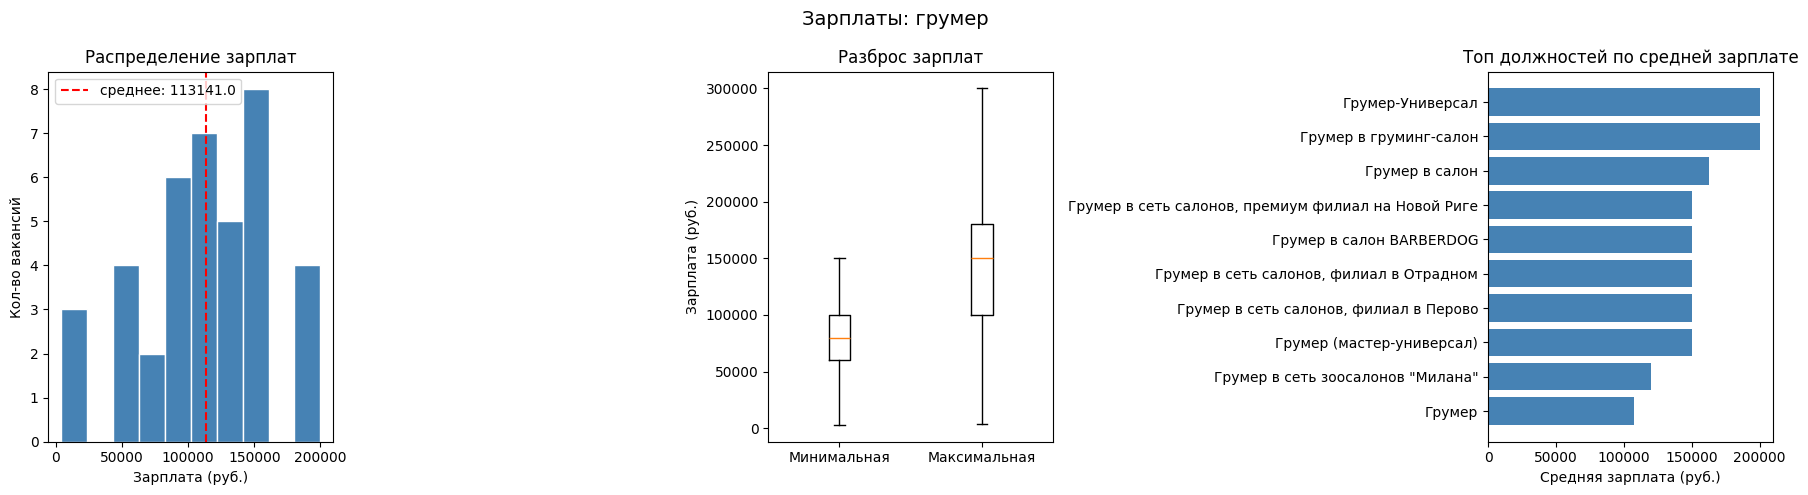

In [236]:
grumers = HHParser('grumer', 'грумер')
grumers.make_everything(0, 1)
print(grumers.mean)
grumers.df.head()

171011.9


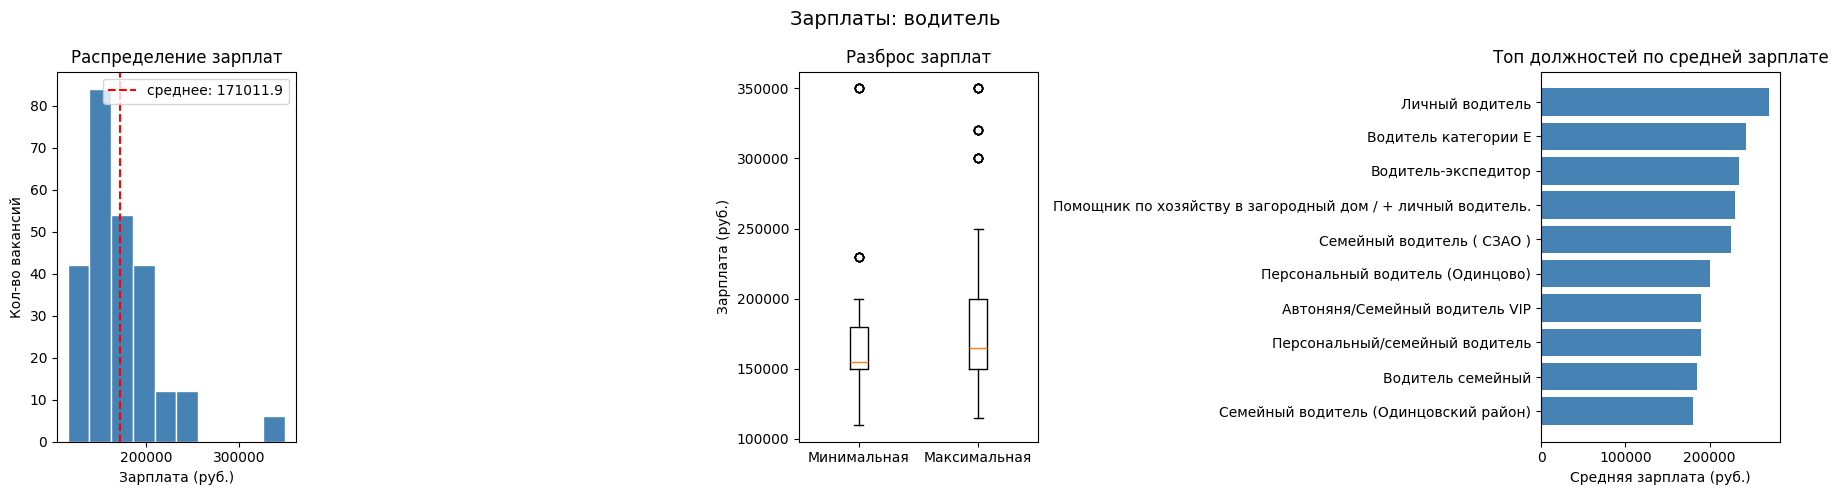

In [237]:
drivers = HHParser('driver', 'водитель')
drivers.make_everything()
print(drivers.mean)

In [203]:
drivers.df.head()

,job,min,max,average
0,Водитель категории Е,166000.0,320000.0,243000.0
1,Личный водитель (Водитель-помощник),160000.0,160000.0,160000.0
2,Водитель,150000.0,150000.0,150000.0
4,Водитель персональный/водитель семейный,160000.0,180000.0,170000.0
5,Личный водитель руководителя на служебный авто...,130000.0,130000.0,130000.0
